In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import matplotlib.font_manager as fm

In [2]:
font_path = "/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Regular.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Work Sans"
work_sans_title = fm.FontProperties(fname="/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Bold.ttf", size=16)
work_sans_axis = fm.FontProperties(fname="/Users/anvi/Desktop/climate_science/utils/fonts/Work_Sans/static/WorkSans-Regular.ttf", size=12)

In [3]:
df = pd.read_csv("/Users/anvi/Desktop/climate_science/GISS_Surface_Temperature_Analysis_v4/data/L_OTI/global/southern_mean.csv", skiprows=1)

In [4]:
print(f"Number of columns in df: {df.shape[1]}")
print(f"Number of rows in df: {df.shape[0]}")

Number of columns in df: 19
Number of rows in df: 147


In [5]:
df

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.01,0.02,0.05,-0.03,-0.14,-0.26,-0.18,0.06,-.06,-.16,-.02,.04,-.06,***,***,-0.04,-0.13,-.08
1,1881,-0.10,-0.07,0.08,0.08,0.08,-0.06,-0.09,-0.03,-.05,-.02,-.02,.08,-.01,-.01,-.04,0.08,-0.06,-.03
2,1882,0.06,0.06,0.06,-0.03,-0.05,-0.16,-0.05,0.00,-.05,.03,-.02,-.08,-.02,-.01,.07,-0.01,-0.07,-.02
3,1883,-0.03,-0.09,-0.10,-0.08,-0.11,-0.03,-0.09,-0.06,-.11,-.06,-.05,-.07,-.07,-.07,-.07,-0.10,-0.06,-.08
4,1884,-0.09,-0.06,-0.11,-0.22,-0.32,-0.30,-0.22,-0.07,-.11,-.07,-.11,-.16,-.16,-.15,-.08,-0.22,-0.20,-.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2022,0.58,0.61,0.67,0.57,0.65,0.71,0.81,0.71,.61,.62,.37,.53,.62,.62,.59,0.63,0.74,.53
143,2023,0.45,0.64,0.81,0.96,0.75,0.98,0.95,0.83,1.29,.83,.85,.87,.85,.82,.54,0.84,0.92,.99
144,2024,0.83,0.94,1.01,0.84,0.88,0.94,0.99,1.17,.87,.96,.71,.83,.91,.92,.88,0.91,1.03,.85
145,2025,0.90,0.88,0.89,0.88,0.94,0.93,0.82,1.05,1.09,.89,.74,.69,.89,.90,.87,0.90,0.93,.91


---

J-D : calendar year average; from the first day of January to the last day of December

D-N : meteorological year average; from the first day of December to the last day of November

In [6]:
df.rename(columns={'Jan':'January', 'Feb':'February', 'Mar':'March', 'Apr':'April', 'May':'May', 'Jun':'June', 'Jul':'July', 'Aug':'August', 'Sep':'September', 'Oct':'October', 'Nov':'November', 'Dec':'December'}, inplace=True)

In [7]:
temp_columns = df.columns.drop('Year')

In [8]:
df[temp_columns] = df[temp_columns].apply(pd.to_numeric, errors='coerce') * 0.01

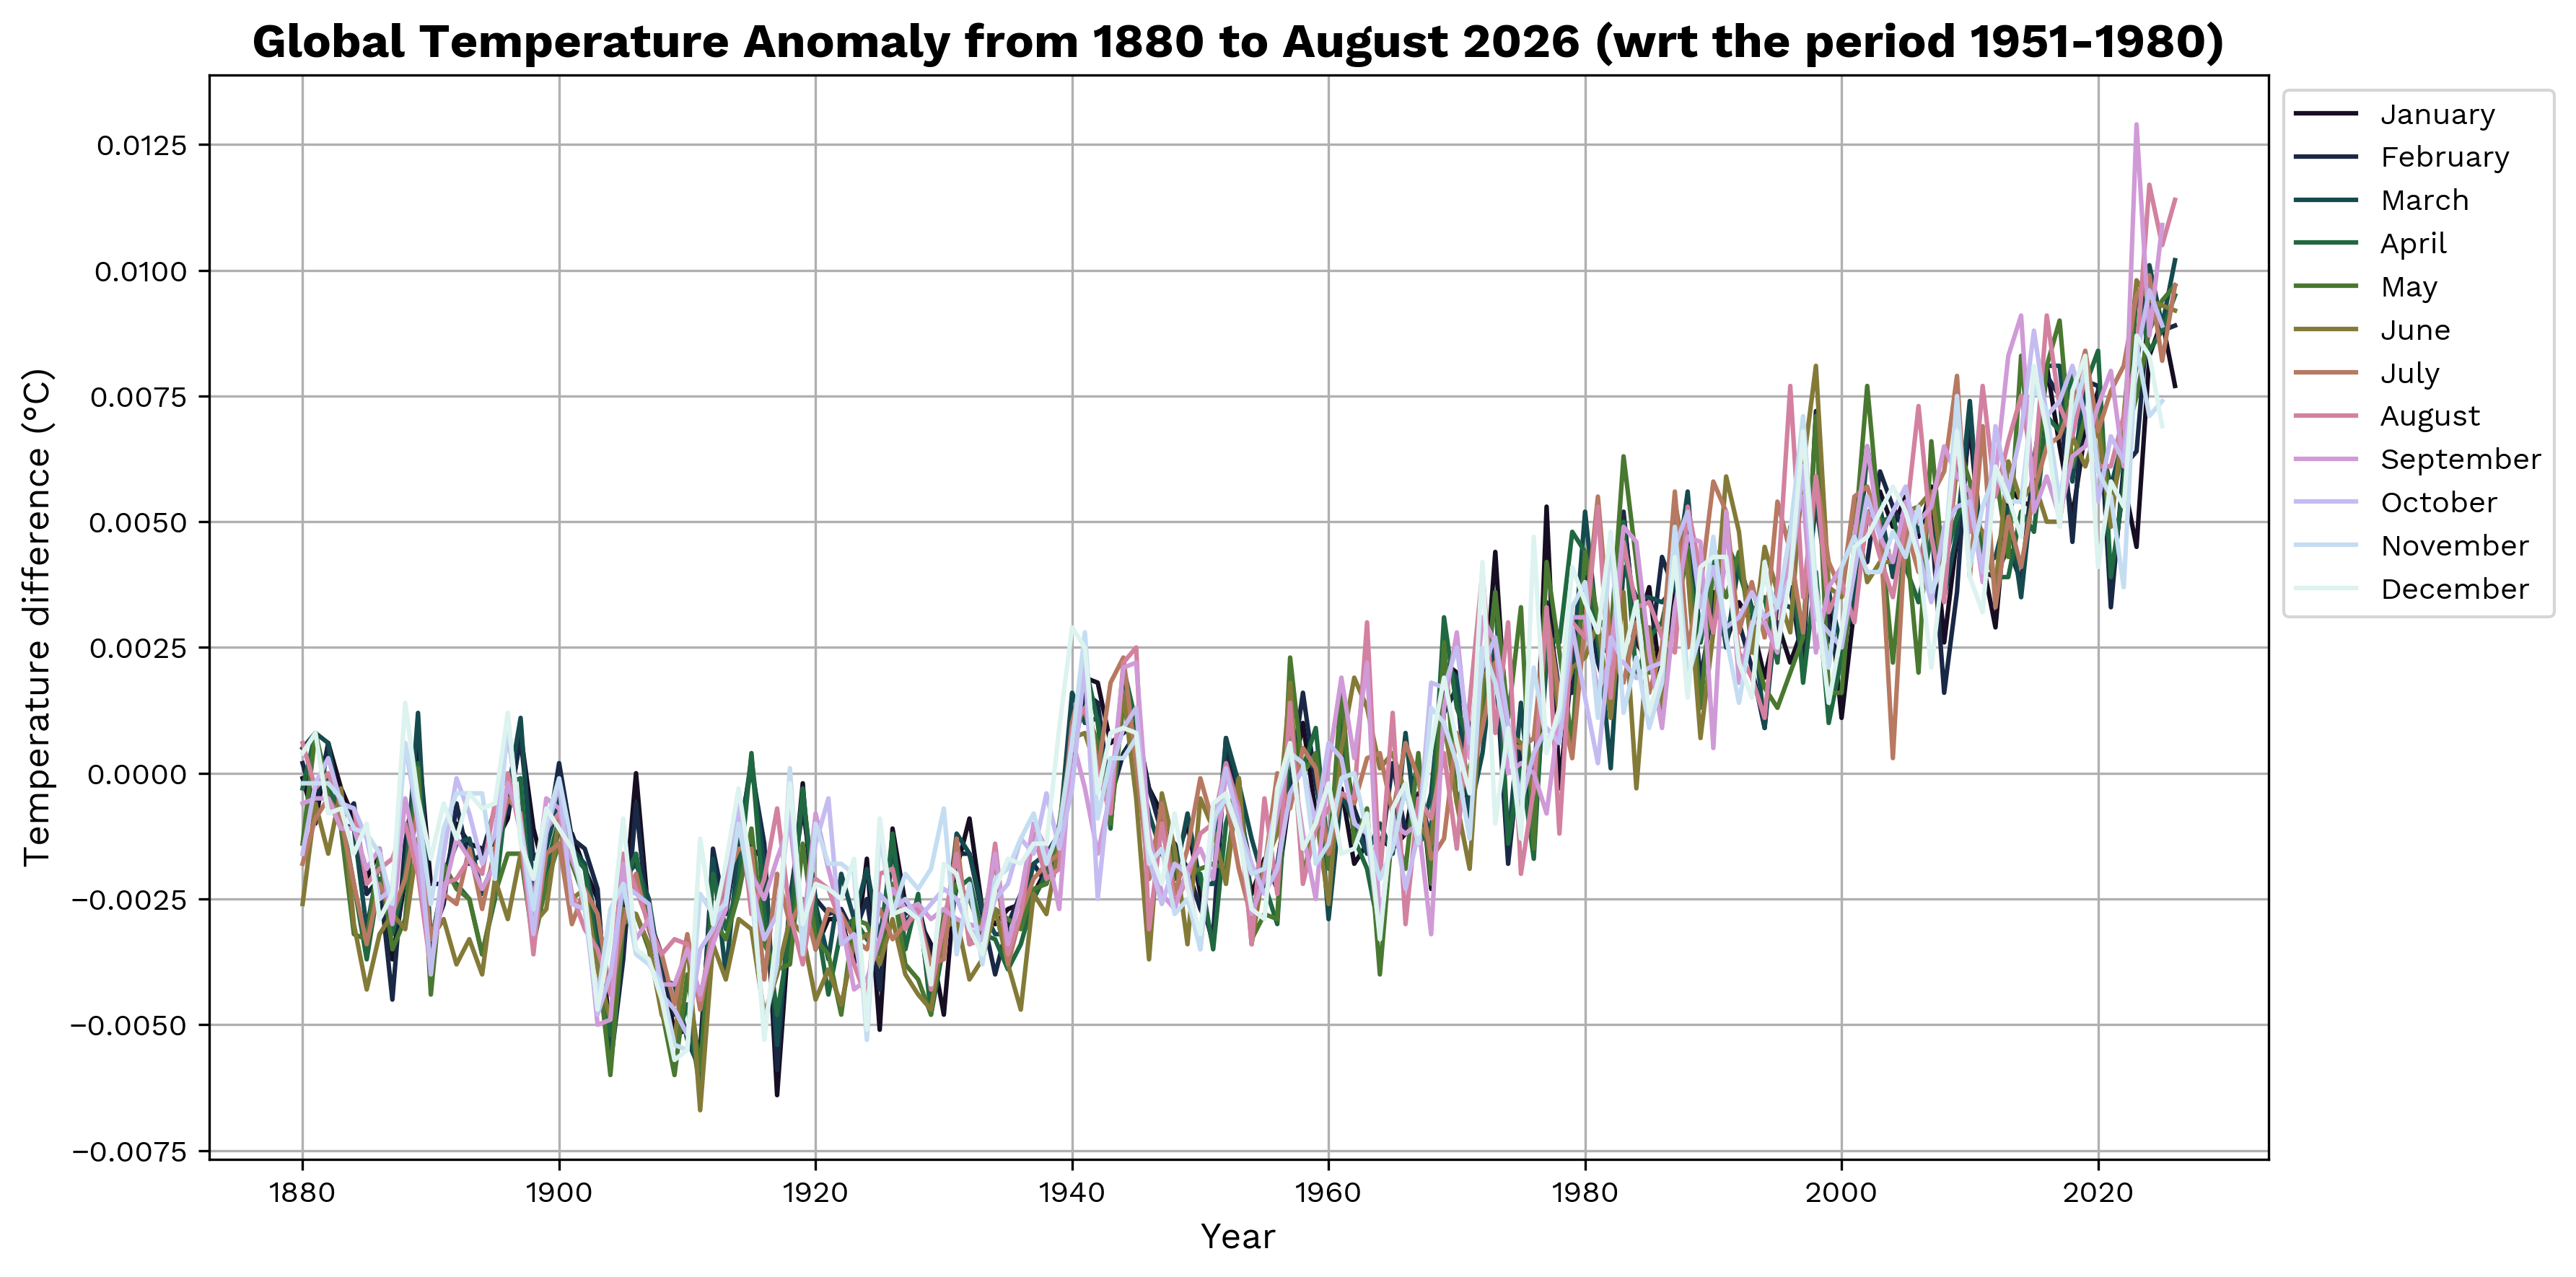

In [9]:
plt.figure(figsize=(12, 6), dpi=300)

monthly_columns = temp_columns[:12]

#defining the color palette for the plot using seaborn's palette
colors = sns.color_palette("cubehelix", n_colors=len(monthly_columns))

#plotting the temperature data for each month
for col in monthly_columns:
    plt.plot(df['Year'], df[col], label=col, color=colors.pop(0))

#plot parameters
plt.xlabel('Year', fontproperties=work_sans_axis)
plt.ylabel('Temperature difference (°C)', fontproperties=work_sans_axis)
plt.title('Global Temperature Anomaly from 1880 to August 2026 (wrt the period 1951-1980)', fontproperties=work_sans_title)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.savefig('/Users/anvi/Desktop/climate_science/notebook/GISS/out/plots/Global_Temperature_Anomaly_1880-2026.png', dpi=1000, bbox_inches='tight')
plt.show()

In [10]:
plt.figure(figsize=(12, 6), dpi=1000)

#defining the color palette for the plot using seaborn's palette
colors = sns.color_palette("magma", n_colors=len(temp_columns[12:14]))

#plotting the temperature data for each month
for col in temp_columns[12:14]:
    plt.plot(df['Year'], df[col], label=col, color=colors.pop(0))

#plot parameters
plt.xlabel('Year', fontproperties=work_sans_axis)
plt.ylabel('Temperature difference (°C)', fontproperties=work_sans_axis)
plt.title('Global Temperature Anomaly from 1880 to August 2026 (wrt the period 1951-1980)', fontproperties=work_sans_title)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
plt.figure(figsize=(12, 6), dpi=1000)

#defining the color palette for the plot using seaborn's palette
colors = sns.color_palette("magma", n_colors=len(temp_columns[14:17:2]))

#plotting the temperature data for each month
for col in temp_columns[14:17:2]:
    plt.plot(df['Year'], df[col], label=col, color=colors.pop(0))

#plot parameters
plt.xlabel('Year', fontproperties=work_sans_axis)
plt.ylabel('Temperature difference (°C)', fontproperties=work_sans_axis)
plt.title('Global Temperature Anomaly from 1880 to August 2026 (wrt the period 1951-1980)', fontproperties=work_sans_title)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
# transforming the months into rows; and inverting to have January at the top and December at the bottom
heatmap_data = df.set_index("Year")[monthly_columns].T.iloc[::-1]

In [13]:
plt.figure(figsize=(14, 6), dpi=1000)

ax = sns.heatmap(
        heatmap_data,
        cmap="RdYlBu_r",
        center=0,
        linewidths=0.1,
        xticklabels=4,
        cbar_kws={"label": "Temperature difference (°C)"}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.xlabel("Year", fontproperties=work_sans_axis)
plt.ylabel("Month", fontproperties=work_sans_axis)
plt.title(
    "Monthly Global Temperature Anomalies",
    fontproperties=work_sans_title
)
plt.tight_layout()
plt.savefig('/Users/anvi/Desktop/climate_science/notebook/GISS/out/heatmaps/Monthly_Global_Temperature_Anomalies.png', dpi=1000, bbox_inches='tight')
plt.show()